In [62]:
# CELL 1 — Retriever import
# This cell is for importing the retrievers since they are in the retriever folder
import sys
from pathlib import Path

# Make the retriever module importable from the notebook root
sys.path.insert(0, str(Path("retriever").resolve()))

print("sys.path updated. Retriever module location:", Path("retriever").resolve())

sys.path updated. Retriever module location: /Users/sidemoctardialla/Desktop/AI-group-project-2026/retriever


# Imports

In [63]:
# CELL 2 — Imports

import json, csv, random, re, time, statistics, urllib.request, urllib.error
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from bm25_retriever import BM25Retriever
from dense_retriever import DenseRetriever
from hybrid_retriever import HybridRetriever

# Configuration

In [64]:
# CELL 3 — Configuration
# Single dictionary controlling the entire experiment. We can change values here

CFG = {
    # Ollama API settings
    "ollama_host":     "http://localhost:11434",  # default Ollama local address
    "timeout_s":       1800,                      # max seconds to wait per call (generous for CPU)
    "num_predict":     512,                       # max tokens the model can generate per response
    "seed":            42,                        # fixed seed for reproducible outputs

    # Models to evaluate, 4b and 8b are too big 
    "models":          ["qwen3:0.6b", "qwen3:1.7b"],

    # Retriever settings
    "knowledge_base":  "knowledge_based/icd11_chunks.json",  # ICD-11 CDDR chunks
    "retriever_types": ["bm25", "dense", "hybrid"],
    "top_k_values":    [1, 3, 5],   # number of chunks retrieved per post
    "hybrid_alpha":    0.5,             # weight between BM25 and dense (0=dense only, 1=BM25 only)

    # Experiment variables
    "prompt_types":    ["zero_shot", "few_shot"],
    "thinking_modes":  [False, True],   # Qwen3 thinking mode on/off

    # Dataset settings
    "dataset_path":    "Depression_Severity_Levels_Dataset.csv", # same route as the notebook
    "text_column":     "text",
    "label_column":    "label",
    "sample_size":     50,    # number of posts to evaluate
    "sample_seed":     42,    # fixed seed for reproducible sampling

    # Classification labels, They are the same as the one in the database
    "labels":          ["minimum", "mild", "moderate", "severe"],
}

# Printing the labels to see if everything works well
print("Configuration loaded.")
print(f"  Models:          {CFG['models']}")
print(f"  Retrievers:      {CFG['retriever_types']}")
print(f"  Top-k values:    {CFG['top_k_values']}")
print(f"  Prompt types:    {CFG['prompt_types']}")
print(f"  Thinking modes:  {CFG['thinking_modes']}")

Configuration loaded.
  Models:          ['qwen3:0.6b', 'qwen3:1.7b']
  Retrievers:      ['bm25', 'dense', 'hybrid']
  Top-k values:    [1, 3, 5]
  Prompt types:    ['zero_shot', 'few_shot']
  Thinking modes:  [False, True]


In [65]:
# # CELL 3b — Smoke Test Override (TEMPORARY)
# # Overrides CFG to run a minimal 5-post test to confirm the pipeline works
# # end-to-end without errors. 
# # REMOVE THIS CELL once real ICD-11 CDDR chunks are in knowledge_based/
# # and replace with the full CFG defined in Cell 3.


# CFG["sample_size"]     = 5
# CFG["models"]          = ["qwen3:0.6b"]
# CFG["retriever_types"] = ["bm25"]
# CFG["top_k_values"]    = [3]
# CFG["prompt_types"]    = ["zero_shot"]
# CFG["thinking_modes"]  = [False]

# print("SMOKE TEST MODE — 5 posts, BM25 only, zero-shot, no thinking")
# print("Replace with full CFG once real CDDR chunks are ready")

# Prompt Builder

In [66]:
import json
with open("knowledge_based/icd11_chunks.json") as f:
    chunks = json.load(f)
print(list(chunks[0].keys()))
print("---")
print("text field:")
print(chunks[0]['text'][:400])

['source', 'domain', 'disorder_code', 'disorder_name', 'section', 'text', 'word_count', 'embed_text']
---
text field:
Other specified anxiety or fear-related disorder Specify presence of panic attacks without co-occurring panic disorder diagnosis 6B0Y/MB23.H Other specified anxiety and fear-related disorder with panic attacks


In [67]:
# CELL 4 — Prompt Builder

# THis cell is for defining the prompt sent to tge LLM along with retrieval block, zero shot or few shot
# We try to force the model to follow this particula structure to avoid inconsistent structure.

SYSTEM_PROMPT = (
    "You are a depression severity classifier. "
    "You must reply with ONLY these two lines, nothing else:\n"
    "Label: <minimum|mild|moderate|severe>\n"
    "Reason: <one sentence>\n"
    "Do NOT give advice. Do NOT explain. Just the two lines above."
)

# Zero-shot: no examples, just the system prompt + retrieved chunks + post
ZERO_SHOT_TEMPLATE = """\
{system}

Post: {post}

Answer:"""

# Few-shot: adds 4 labeled examples before the post to guide the model
FEW_SHOT_TEMPLATE = """\
{system}

Examples:
Post: "I feel a bit down today but I'm managing fine at work."
Label: minimum — Mood is slightly low but functioning is largely unaffected.

Post: "I've been sad most days, struggling to enjoy anything, sleep is off."
Label: mild — Several depressive symptoms present but daily functioning is mostly preserved.

Post: "I can barely get out of bed. I've lost my job, I feel worthless, nothing matters."
Label: moderate — Multiple severe symptoms causing considerable functional impairment.

Post: "I don't see the point in living. I haven't eaten in days, I can't speak to anyone."
Label: severe — Near-complete functional collapse with passive suicidal ideation.

---
Post: {post}

Answer:"""

# Template for injecting retrieved CDDR chunks between the system prompt and the post
RETRIEVAL_BLOCK_TEMPLATE = """\

Relevant clinical knowledge:
{chunks}
---
"""

def build_prompt(post: str, prompt_type: str,
                 retrieved_chunks: list[dict]) -> str:
    """Assemble the final prompt from template + optional retrieved chunks.
    
    Args:
        post:             The social media post to classify.
        prompt_type:      "zero_shot" or "few_shot"
        retrieved_chunks: List of chunk dicts returned by the retriever.
                          Empty list = no retrieval (baseline condition).
    Returns:
        The complete prompt string ready to send to Ollama.
    """
    # Format retrieved chunks as a numbered list if any were returned
    chunk_text = ""
    if retrieved_chunks:
        bullets = "\n".join(
            f"[{i+1}] ({c.get('disorder_name', '')} — {c.get('section', '')}): "
            f"{c.get('prompt_text', c.get('text', ''))[:300]}"
            for i, c in enumerate(retrieved_chunks)
        )
        chunk_text = RETRIEVAL_BLOCK_TEMPLATE.format(chunks=bullets)

    # Attach retrieval block to system prompt, then fill in the template
    template = ZERO_SHOT_TEMPLATE if prompt_type == "zero_shot" else FEW_SHOT_TEMPLATE
    full_system = SYSTEM_PROMPT + chunk_text
    return template.format(system=full_system, post=post)

# Sanity check prints the assembled prompt for a sample post
sample_chunks = [{"text": "Depressed mood: persistent low mood most of the day..."}]
print(build_prompt("I feel really hopeless lately.", "zero_shot", sample_chunks))

You are a depression severity classifier. You must reply with ONLY these two lines, nothing else:
Label: <minimum|mild|moderate|severe>
Reason: <one sentence>
Do NOT give advice. Do NOT explain. Just the two lines above.
Relevant clinical knowledge:
[1] ( — ): Depressed mood: persistent low mood most of the day...
---


Post: I feel really hopeless lately.

Answer:


# Load Dataset

In [68]:
# CELL 5 — Load Dataset
# Loads the depression severity dataset, filters out unusable rows,
# and returns a reproducible random sample for evaluation.


def load_dataset(cfg: dict) -> pd.DataFrame:
    # We defined the csv field sizelimit because defult one is quiet small
    csv.field_size_limit(10_000_000)
    path = cfg["dataset_path"]
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            text  = (r.get(cfg["text_column"])  or "").strip()
            label = (r.get(cfg["label_column"]) or "").strip().lower()
            # Skip rows with missing text or labels not in our valid label set
            if text and label in cfg["labels"]:
                rows.append({"text": text, "label": label})

    df = pd.DataFrame(rows)
    print(f"Total usable rows: {len(df)}")
    print(df["label"].value_counts().to_string())

    # Reproducible random sample — same seed always gives the same posts
    random.seed(cfg["sample_seed"])
    idx = random.sample(range(len(df)), min(cfg["sample_size"], len(df)))
    sample = df.iloc[idx].reset_index(drop=True)
    print(f"\nSampled {len(sample)} posts for evaluation.")
    return sample

df_posts = load_dataset(CFG)
df_posts.head()

Total usable rows: 41859
label
severe      11176
mild        10661
minimum     10549
moderate     9473

Sampled 50 posts for evaluation.


,text,label
0,"As I’ve gotten quieter over the years, friends...",moderate
1,That was enough back then. Matt was always gre...,minimum
2,"Hello, first time poster.Sigh, I am just so st...",mild
3,I have been working hard for the last year to ...,mild
4,I am sitting in the hospital bed. Not for tryi...,mild


# Build Retrievers

In [69]:
# CELL 6 — Build Retrievers
# Initialises all three retrievers from the same knowledge base file.


def build_retrievers(cfg: dict) -> dict:
    kb = cfg["knowledge_base"]
    print(f"Building retrievers from: {kb}")
    
    # Stop early with a clear message if the knowledge base file is missing
    assert Path(kb).exists(), f"Knowledge base not found at {kb}"

    retrievers = {}

    print("  → BM25  ...", end=" ", flush=True)
    retrievers["bm25"]   = BM25Retriever(json_path=kb)

    print("  → Dense ...", end=" ", flush=True)
    retrievers["dense"]  = DenseRetriever(json_path=kb)

    print("  → Hybrid ...", end=" ", flush=True)

    # alpha=0.5 means equal weight between BM25 and dense scores
    # < 0.5 means giving more weight to the dense retriever and > 0.5 more weight to the BM25
    # We can also optimise this parameter to find the best trade of ([0.3, 0.5, 0.8])
    retrievers["hybrid"] = HybridRetriever(json_path=kb, alpha=cfg["hybrid_alpha"])

    print("\nAll retrievers ready.")
    return retrievers

retrievers = build_retrievers(CFG)

Building retrievers from: knowledge_based/icd11_chunks.json
  → BM25  ... BM25 retriever ready: 1080 chunks indexed
  → Dense ... Dense retriever ready: 1080 chunks indexed (384 dims)
  → Hybrid ... BM25 retriever ready: 1080 chunks indexed
Dense retriever ready: 1080 chunks indexed (384 dims)

All retrievers ready.


# Ollama Helpers

In [70]:
# CELL 7 — Ollama Helpers
# In this cell we defines the functions that will help us communicate with Ollama API

# Sends a POST request to Ollama and returns the response
def _http_post(host: str, path: str, payload: dict, timeout: int) -> dict:
    # Sends a JSON POST request to the Ollama API and returns the parsed response
    req = urllib.request.Request(
        host + path,
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode())

# Confirms Ollama is running and required models are pulled
def check_ollama(cfg: dict) -> list[str]:
    req = urllib.request.Request(cfg["ollama_host"] + "/api/tags")
    with urllib.request.urlopen(req, timeout=10) as r:
        data = json.loads(r.read().decode())
    installed = [m["name"] for m in data.get("models", [])]
    print("Ollama is running. Installed models:")
    for m in installed:
        print(f"  {m}")
    missing = [m for m in cfg["models"]
               if not any(i == m or i.startswith(m) for i in installed)]
    if missing:
        print(f"\nWARNING — these models are not pulled yet: {missing}")
        print("Run:  ollama pull <model>  for each one before the grid sweep.")
    return installed

installed_models = check_ollama(CFG)

#  Extracts the classification label from the model's output
def _parse_label(text: str, valid_labels: list[str]) -> str:
    # First tries to match the expected "Label: <label>" format
    match = re.search(r'label:\s*(\w+)', text.lower())
    if match and match.group(1) in valid_labels:
        return match.group(1)
    # Fallback — scans the full output for the first valid label word
    # handles cases where the model ignores the format instruction
    for label in valid_labels:
        if label in text.lower():
            return label
    return "unknown"  # returned when no valid label found at all

# Separates the thinking trace from the actual answer
def _split_thinking(response_text: str, thinking_field: str) -> tuple[str, str]:
    # Newer Ollama versions return thinking in a separate field
    if thinking_field:
        return thinking_field.strip(), response_text.strip()
    # Older versions embed thinking inline as <think>...</think> tags
    m = re.search(r"<think>(.*?)</think>", response_text, re.DOTALL)
    if m:
        return m.group(1).strip(), response_text[m.end():].strip()
    # Thinking mode was off — return empty thinking and full response as answer
    return "", response_text.strip()

# Sends a prompt to a model and returns timing + output
def call_ollama(prompt: str, model: str, think: bool, cfg: dict) -> dict:
    # Builds the request payload and sends it to Ollama
    payload = {
        "model":  model,
        "prompt": prompt,
        "think":  think,   # toggles Qwen3 thinking/reasoning mode
        "stream": False,   # wait for full response before returning
        "options": {
            "seed":        cfg["seed"],        # fixed for reproducibility
            "num_predict": cfg["num_predict"], # max tokens to generate
        },
    }
    t0 = time.perf_counter()
    resp = _http_post(cfg["ollama_host"], "/api/generate", payload, cfg["timeout_s"])
    wall_s = time.perf_counter() - t0

    raw_response   = resp.get("response", "")
    thinking_field = resp.get("thinking", "") or ""
    thinking_text, answer_text = _split_thinking(raw_response, thinking_field)

    gen_eval_s = resp.get("eval_duration", 0) / 1e9
    gen_tokens  = resp.get("eval_count", 0)

    return {
        "wall_s":        round(wall_s, 3),
        "total_s":       round(resp.get("total_duration", 0) / 1e9, 3),
        "prompt_tokens": resp.get("prompt_eval_count", 0),
        "gen_tokens":    gen_tokens,
        "tok_per_s":     round(gen_tokens / gen_eval_s, 2) if gen_eval_s else 0.0,
        "thinking_text": thinking_text,
        "answer_text":   answer_text,
        "hit_cap":       gen_tokens >= cfg["num_predict"], # True if model hit the token limit
    }

print("Ollama helpers ready.")

Ollama is running. Installed models:
  qwen3:1.7b
  qwen3:0.6b
  llama3.1:8b
  nomic-embed-text:latest
Ollama helpers ready.


# Pipeline Runner

In [71]:
# CELL 8 — Pipeline Runner
# run_single() is the core of the pipeline. It takes one post and one
# experiment configuration, runs it through the full RAG pipeline, and
# returns a results dict with the prediction, timing, and retrieved chunks.
# Called once per post per configuration in the experiment grid.


def run_single(
    post: str,
    true_label: str,
    model: str,
    retriever_type: str,
    top_k: int,
    prompt_type: str,
    think: bool,
    retrievers: dict,
    cfg: dict,
) -> dict:

    # Step 1 — Retrieve top-k relevant CDDR chunks for this post
    t_ret = time.perf_counter()
    chunks = retrievers[retriever_type].search(post, k=top_k)
    retrieval_s = round(time.perf_counter() - t_ret, 4)

    # Step 2 — Assemble the prompt (system + retrieved chunks + post)
    prompt = build_prompt(post, prompt_type, chunks)

    # Step 3 — Send prompt to the LLM and get response + timing
    llm_out = call_ollama(prompt, model, think, cfg)

    # Step 4 — Extract the predicted label from the model's raw output
    predicted = _parse_label(llm_out["answer_text"], cfg["labels"])

    return {
        # Experiment configuration axes
        "model":           model,
        "retriever":       retriever_type,
        "top_k":           top_k,
        "prompt_type":     prompt_type,
        "think":           think,
        # Ground truth and prediction
        "true_label":      true_label,
        "predicted":       predicted,
        "correct":         int(predicted == true_label),
        # Timing
        "retrieval_s":     retrieval_s,
        "llm_total_s":     llm_out["total_s"],
        "tok_per_s":       llm_out["tok_per_s"],
        "prompt_tokens":   llm_out["prompt_tokens"],
        "gen_tokens":      llm_out["gen_tokens"],
        "hit_cap":         llm_out["hit_cap"],
        # Retrieved evidence (kept for retrieval quality analysis)
        "chunks_returned": len(chunks),
        "chunk_ids": [c.get("id", c.get("disorder_code", "")) for c in chunks],
        # Raw model output (kept for error analysis)
        "answer_text":     llm_out["answer_text"],
        "thinking_text":   llm_out["thinking_text"],
    }

print("run_single() defined.")

run_single() defined.


In [72]:
# CELL 9 — Model Warmup
# Sends one dummy call to each model before the timed experiment grid.
# Without this, the first real post would be slower than the rest because
# Ollama needs to load the model weights into RAM on the first call.
# Warmup results are discarded — only used to pre-load the model.

print("Warming up models (one call each, results discarded) ...")
for model in CFG["models"]:
    try:
        call_ollama("Hello", model, False, CFG)
        print(f"  ✓ {model}")
    except Exception as e:
        print(f"  ✗ {model}  — {e}")
print("Warmup done.")

Warming up models (one call each, results discarded) ...
  ✓ qwen3:0.6b
  ✓ qwen3:1.7b
Warmup done.


In [73]:
# CELL 10 — Full Experiment Grid (COMMENTED OUT — use Cell 12 instead)
# Runs every possible combination of all CFG variables using itertools.product.
# With current CFG this produces:
#   2 models × 3 retrievers × 4 top-k × 2 prompt types × 2 thinking modes
#   = 96 configurations × 50 posts = 4800 LLM calls
# Estimated time on CPU: many hours — not practical for development.
# Use the targeted grid in Cell 12 which runs ~1000 calls instead.


# # Build all combinations of experiment variables into a flat list of tuples
# grid = list(product(
#     CFG["models"],
#     CFG["retriever_types"],
#     CFG["top_k_values"],
#     CFG["prompt_types"],
#     CFG["thinking_modes"],
# ))
# total_calls = len(grid) * len(df_posts)
# print(f"Grid size: {len(grid)} configurations × {len(df_posts)} posts = {total_calls} LLM calls")
# print("This will take a while on CPU. Consider reducing models/top_k_values/sample_size for dev runs.\n")
#
# # Loop over every configuration, then every post within each configuration
# all_results = []
# for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
#     config_label = (f"{model} | {retriever_type} | k={top_k} | "
#                     f"{prompt_type} | think={think}")
#     print(f"\n[{config_idx+1}/{len(grid)}] {config_label}")
#
#     for post_idx, row in df_posts.iterrows():
#         try:
#             # Run one post through the full pipeline for this configuration
#             result = run_single(
#                 post          = row["text"],
#                 true_label    = row["label"],
#                 model         = model,
#                 retriever_type= retriever_type,
#                 top_k         = top_k,
#                 prompt_type   = prompt_type,
#                 think         = think,
#                 retrievers    = retrievers,
#                 cfg           = CFG,
#             )
#             all_results.append(result)
#             status = "✓" if result["correct"] else "✗"
#             print(f"  {status} post{post_idx:02d} | "
#                   f"true={result['true_label']:8} pred={result['predicted']:8} | "
#                   f"llm={result['llm_total_s']:.1f}s  ret={result['retrieval_s']:.3f}s")
#         except Exception as e:
#             # Log errors per post without stopping the whole run
#             print(f"  ERROR post{post_idx}: {e}")
#
# # Save all results to CSV and display first few rows
# df_results = pd.DataFrame(all_results)
# df_results.to_csv("rag_results_raw.csv", index=False)
# print(f"\nDone. {len(df_results)} rows saved to rag_results_raw.csv")
# df_results.head()

# Experiment

In [74]:
# CELL 11 — Targeted Experiment Grid
# Instead of running every possible combination (Cell 10), this cell runs
# a targeted grid that answers five specific research questions (RQs).
# Each RQ isolates one variable while keeping the others fixed.
# Total: ~19 configurations × 50 posts = ~950 LLM calls (~8 mins on CPU)

grid = []

# RQ1: Does retrieval method affect classification accuracy?
# Sweeps all three retrievers across all top-k values
# Everything else fixed: 0.6b, zero-shot, no thinking
for ret in ["bm25", "dense", "hybrid"]:
    for k in [1, 3, 5, 7]:
        grid.append(("qwen3:0.6b", ret, k, "zero_shot", False))

# RQ2: Does model size affect classification accuracy?
# Compares 0.6b vs 1.7b with the best retriever (hybrid, k=5)
for model in ["qwen3:0.6b", "qwen3:1.7b"]:
    grid.append((model, "hybrid", 5, "zero_shot", False))

# RQ3: Does thinking mode improve accuracy?
# Adds thinking ON for 0.6b — compare against RQ2's 0.6b thinking OFF result
grid.append(("qwen3:0.6b", "hybrid", 5, "zero_shot", True))

# RQ4: Does few-shot prompting improve accuracy over zero-shot?
# Same config as RQ2 0.6b but with few-shot examples in the prompt
grid.append(("qwen3:0.6b", "hybrid", 5, "few_shot", False))

# RQ5: Does RAG actually help? (no-retrieval baseline)
# k=0 means no chunks are retrieved — prompt contains only the post
# Compare this against RQ1 results to measure RAG's contribution
grid.append(("qwen3:0.6b", "bm25", 0, "zero_shot", False))

# Print the full grid before running so it can be reviewed
posts_to_run = df_posts.head(CFG["sample_size"])
total_calls = len(grid) * len(posts_to_run)
out_file = "rag_results_final.csv"

print(f"Grid: {len(grid)} configs × {len(posts_to_run)} posts = {total_calls} calls")
print(f"Output: {out_file}")
print(f"Est. time: ~{total_calls * 0.5 / 60:.1f} min\n")
for i, (m, r, k, p, t) in enumerate(grid):
    print(f"  [{i+1:2d}] {m:14} {r:8} k={k} {p:10} think={t}")

# Run the grid — try/finally ensures partial results are saved even if
# the run crashes or is interrupted halfway through
all_results = []
try:
    for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
        label = f"{model} | {retriever_type} | k={top_k} | {prompt_type} | think={think}"
        print(f"\n[{config_idx+1}/{len(grid)}] {label}")

        for post_idx, row in posts_to_run.iterrows():
            try:
                result = run_single(
                    post=row["text"], true_label=row["label"],
                    model=model, retriever_type=retriever_type,
                    top_k=top_k, prompt_type=prompt_type,
                    think=think, retrievers=retrievers, cfg=CFG,
                )
                all_results.append(result)
                s = "✓" if result["correct"] else "✗"
                print(f"  {s} post{post_idx:02d} | true={result['true_label']:8} pred={result['predicted']:8} | llm={result['llm_total_s']:.1f}s")
            except Exception as e:
                # Log errors per post without stopping the whole run
                print(f"  ERROR post{post_idx}: {e}")

finally:
    # Always save whatever results were collected — even on crash or interrupt
    if all_results:
        df_results = pd.DataFrame(all_results)
        df_results.to_csv(out_file, index=False)
        print(f"\nSaved {len(df_results)} rows to {out_file}")

Grid: 17 configs × 50 posts = 850 calls
Output: rag_results_final.csv
Est. time: ~7.1 min

  [ 1] qwen3:0.6b     bm25     k=1 zero_shot  think=False
  [ 2] qwen3:0.6b     bm25     k=3 zero_shot  think=False
  [ 3] qwen3:0.6b     bm25     k=5 zero_shot  think=False
  [ 4] qwen3:0.6b     bm25     k=7 zero_shot  think=False
  [ 5] qwen3:0.6b     dense    k=1 zero_shot  think=False
  [ 6] qwen3:0.6b     dense    k=3 zero_shot  think=False
  [ 7] qwen3:0.6b     dense    k=5 zero_shot  think=False
  [ 8] qwen3:0.6b     dense    k=7 zero_shot  think=False
  [ 9] qwen3:0.6b     hybrid   k=1 zero_shot  think=False
  [10] qwen3:0.6b     hybrid   k=3 zero_shot  think=False
  [11] qwen3:0.6b     hybrid   k=5 zero_shot  think=False
  [12] qwen3:0.6b     hybrid   k=7 zero_shot  think=False
  [13] qwen3:0.6b     hybrid   k=5 zero_shot  think=False
  [14] qwen3:1.7b     hybrid   k=5 zero_shot  think=False
  [15] qwen3:0.6b     hybrid   k=5 zero_shot  think=True
  [16] qwen3:0.6b     hybrid   k=5 few_s

In [75]:
# # CELL 11a — Smoke Test Grid (TEMPORARY — remove with Cell 3b)
# # Runs a single configuration on 5 posts to confirm the pipeline works
# # end-to-end before committing to the full experiment grid.
# # REMOVE THIS CELL once real ICD-11 CDDR chunks are ready and replace
# # with Cell 12 (targeted grid) for the actual experiment run.


# grid = [("qwen3:0.6b", "bm25", 3, "zero_shot", False)]
# posts_to_run = df_posts  # already limited to 5 by CFG override in Cell 4

# total_calls = len(grid) * len(posts_to_run)
# print(f"Smoke test: {len(grid)} config × {len(posts_to_run)} posts = {total_calls} LLM calls")

# all_results = []
# for config_idx, (model, retriever_type, top_k, prompt_type, think) in enumerate(grid):
#     print(f"\n[{config_idx+1}/{len(grid)}] {model} | {retriever_type} | k={top_k} | {prompt_type} | think={think}")

#     for post_idx, row in posts_to_run.iterrows():
#         try:
#             result = run_single(
#                 post=row["text"], true_label=row["label"],
#                 model=model, retriever_type=retriever_type,
#                 top_k=top_k, prompt_type=prompt_type,
#                 think=think, retrievers=retrievers, cfg=CFG,
#             )
#             all_results.append(result)
#             s = "✓" if result["correct"] else "✗"
#             print(f"  {s} post{post_idx:02d} | true={result['true_label']:8} pred={result['predicted']:8} | llm={result['llm_total_s']:.1f}s")
#         except Exception as e:
#             print(f"  ERROR post{post_idx}: {e}")

# df_results = pd.DataFrame(all_results)
# print(f"\nDone. {len(df_results)} rows saved.")
# df_results.head()

In [76]:
# CELL 13 — Results Summary
# Aggregates raw results into a summary table grouped by experiment variables.
# For each configuration computes:
#   n          — number of posts evaluated
#   accuracy   — proportion of correct predictions
#   macro_f1   — macro-averaged F1 across all four labels (main metric)
#                macro-F1 is preferred over accuracy here because it treats
#                all classes equally regardless of their size in the sample
#   mean_llm_s — average LLM inference time per post
#   mean_ret_s — average retrieval time per post

def summarise(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    records = []
    for keys, grp in df.groupby(group_cols):
        # groupby returns a scalar when grouping by one column, tuple for multiple
        if not isinstance(keys, tuple):
            keys = (keys,)
        rec = dict(zip(group_cols, keys))
        rec["n"]        = len(grp)
        rec["accuracy"] = round(grp["correct"].mean(), 4)
        # macro-F1 requires predictions for all labels to be meaningful —
        # use try/except to handle edge cases where a label has no predictions
        try:
            rec["macro_f1"] = round(
                f1_score(grp["true_label"], grp["predicted"],
                         labels=CFG["labels"], average="macro",
                         zero_division=0), 4)
        except Exception:
            rec["macro_f1"] = float("nan")
        rec["mean_llm_s"] = round(grp["llm_total_s"].mean(), 2)
        rec["mean_ret_s"] = round(grp["retrieval_s"].mean(), 4)
        records.append(rec)
    # Sort by macro_f1 descending so best configurations appear first
    return pd.DataFrame(records).sort_values("macro_f1", ascending=False)

# Summarise at the full configuration level — one row per unique combination
# of model, retriever, top_k, prompt_type, and thinking mode
df_summary = summarise(
    df_results,
    ["model", "retriever", "top_k", "prompt_type", "think"]
)
print("Top 10 configurations by macro-F1:")
df_summary.head(10)

Top 10 configurations by macro-F1:


,model,retriever,top_k,prompt_type,think,n,accuracy,macro_f1,mean_llm_s,mean_ret_s
11,qwen3:0.6b,hybrid,5,few_shot,False,50,0.32,0.2586,0.65,0.0402
6,qwen3:0.6b,dense,3,zero_shot,False,50,0.36,0.2282,0.91,0.0262
1,qwen3:0.6b,bm25,1,zero_shot,False,50,0.36,0.2279,0.44,0.0207
9,qwen3:0.6b,hybrid,1,zero_shot,False,50,0.36,0.2279,0.61,0.1228
0,qwen3:0.6b,bm25,0,zero_shot,False,50,0.32,0.2134,0.58,0.0273
4,qwen3:0.6b,bm25,7,zero_shot,False,50,0.32,0.2028,0.63,0.0244
10,qwen3:0.6b,hybrid,3,zero_shot,False,50,0.30,0.1857,0.77,0.0433
7,qwen3:0.6b,dense,5,zero_shot,False,50,0.28,0.1773,0.83,0.0298
8,qwen3:0.6b,dense,7,zero_shot,False,50,0.28,0.1764,0.88,0.0228
5,qwen3:0.6b,dense,1,zero_shot,False,50,0.28,0.1763,0.67,0.1112


In [77]:
# CELL 14 — Per-Axis Summary
# Breaks down results by each experimental variable independently.
# Each axis answers one research question by averaging across all other variables:
#   Model size     → does 1.7b outperform 0.6b?
#   Retriever type → does hybrid outperform BM25 or dense alone?
#   Top-k          → how many retrieved chunks gives the best F1?
#   Prompt type    → does few-shot improve over zero-shot?
#   Thinking mode  → does thinking ON improve accuracy?

axes = {
    "Model size":    ["model"],
    "Retriever type":["retriever"],
    "Top-k":         ["top_k"],
    "Prompt type":   ["prompt_type"],
    "Thinking mode": ["think"],
}

# Print a summary table for each axis — sorted by macro_f1 descending
for axis_name, cols in axes.items():
    print(f"\n── {axis_name} ─────────────────────────────")
    print(summarise(df_results, cols).to_string(index=False))


── Model size ─────────────────────────────
     model   n  accuracy  macro_f1  mean_llm_s  mean_ret_s
qwen3:0.6b 800      0.28    0.1940        0.99      0.0488
qwen3:1.7b  50      0.18    0.1352        2.53      0.0790

── Retriever type ─────────────────────────────
retriever   n  accuracy  macro_f1  mean_llm_s  mean_ret_s
   hybrid 400    0.2475    0.2024        1.54      0.0683
    dense 200    0.3000    0.1893        0.82      0.0475
     bm25 250    0.2960    0.1880        0.54      0.0246

── Top-k ─────────────────────────────
 top_k   n  accuracy  macro_f1  mean_llm_s  mean_ret_s
     0  50    0.3200    0.2134        0.58      0.0273
     1 150    0.3333    0.2106        0.58      0.0849
     5 350    0.2343    0.1962        1.61      0.0543
     3 150    0.2933    0.1834        0.73      0.0317
     7 150    0.2733    0.1733        0.85      0.0340

── Prompt type ─────────────────────────────
prompt_type   n  accuracy  macro_f1  mean_llm_s  mean_ret_s
   few_shot  50    0.

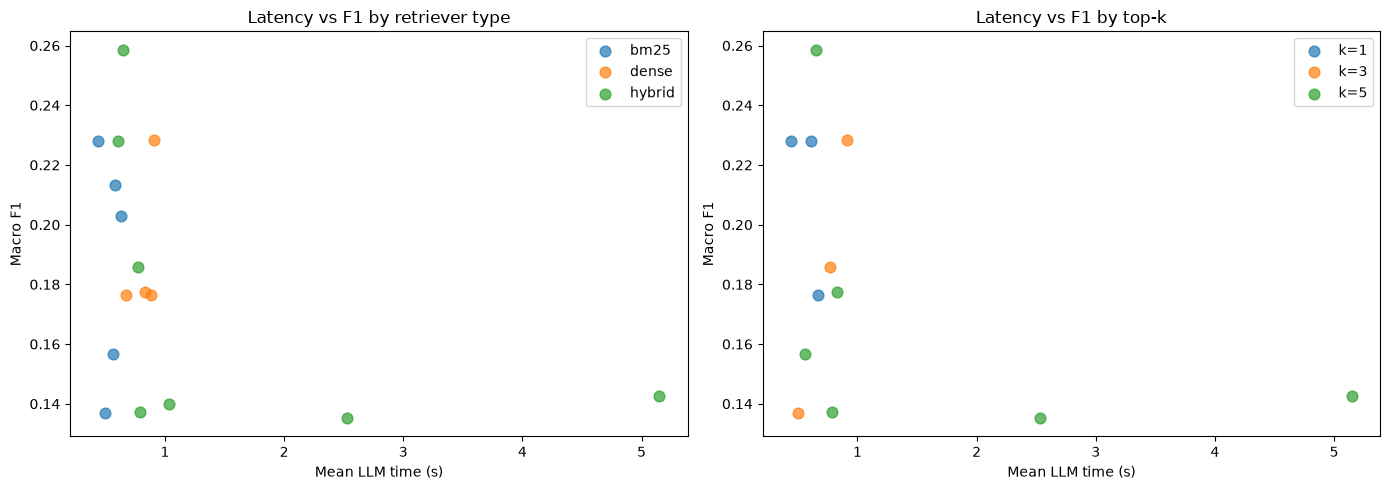

In [78]:
# CELL 15 — Latency vs F1 Plot
# Scatter plot comparing inference speed against classification accuracy.
# Helps identify configurations that are both fast and accurate —
# a configuration in the top-left is ideal (high F1, low latency).


fig, axes_arr = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — each retriever type gets its own colour
# shows whether retrieval method affects the speed/accuracy trade-off
for ret in CFG["retriever_types"]:
    sub = df_summary[df_summary["retriever"] == ret]
    axes_arr[0].scatter(sub["mean_llm_s"], sub["macro_f1"],
                        label=ret, alpha=0.7, s=60)
axes_arr[0].set_xlabel("Mean LLM time (s)")
axes_arr[0].set_ylabel("Macro F1")
axes_arr[0].set_title("Latency vs F1 by retriever type")
axes_arr[0].legend()

# Right plot — each top-k value gets its own colour
# shows whether retrieving more chunks improves F1 at the cost of speed
for k in CFG["top_k_values"]:
    sub = df_summary[df_summary["top_k"] == k]
    axes_arr[1].scatter(sub["mean_llm_s"], sub["macro_f1"],
                        label=f"k={k}", alpha=0.7, s=60)
axes_arr[1].set_xlabel("Mean LLM time (s)")
axes_arr[1].set_ylabel("Macro F1")
axes_arr[1].set_title("Latency vs F1 by top-k")
axes_arr[1].legend()

plt.tight_layout()
plt.show()

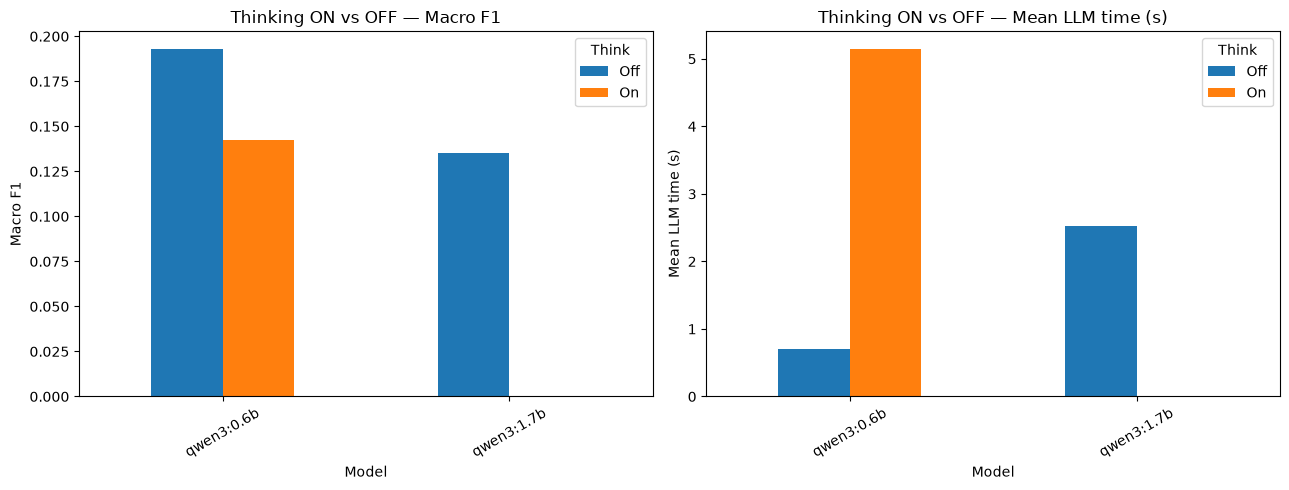

In [79]:
# CELL 16 — Thinking Mode Comparison Plot
# Bar chart comparing thinking ON vs OFF across models for two metrics:
#   Left  — macro F1 (does thinking improve accuracy?)
#   Right — mean LLM time (how much slower is thinking mode?)

# Summarise results grouped by model and thinking mode
think_summary = summarise(df_results, ["model", "think"])

fig, axes_arr = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes_arr,
    ["macro_f1",    "mean_llm_s"],
    ["Macro F1",    "Mean LLM time (s)"],
):
    # Pivot so rows=models, columns=think on/off — makes bar chart easy to plot
    pivot = think_summary.pivot(index="model", columns="think", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Thinking ON vs OFF — {title}")
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    ax.legend(title="Think", labels=["Off", "On"])
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Best configuration:
model          qwen3:0.6b
retriever          hybrid
top_k                   5
prompt_type      few_shot
think               False
accuracy             0.32
macro_f1           0.2586
mean_llm_s           0.65


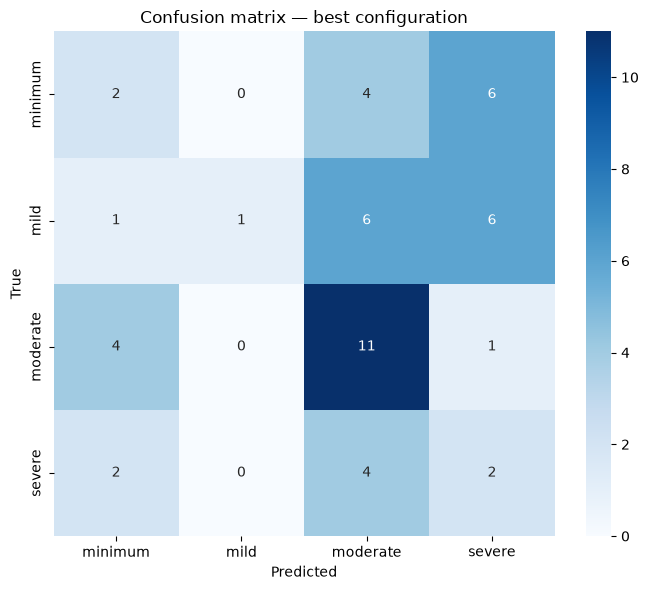


Classification report:
              precision    recall  f1-score   support

     minimum       0.22      0.17      0.19        12
        mild       1.00      0.07      0.13        14
    moderate       0.44      0.69      0.54        16
      severe       0.13      0.25      0.17         8

    accuracy                           0.32        50
   macro avg       0.45      0.29      0.26        50
weighted avg       0.50      0.32      0.28        50



In [80]:
# CELL 17 — Best Configuration Analysis
# Identifies the best performing configuration by macro-F1 and produces:
#   - A confusion matrix showing where the model makes errors
#   - A full classification report with per-class precision, recall, F1
# The confusion matrix is particularly useful for spotting if the model
# confuses adjacent severity levels (e.g. mild vs moderate) more than
# distant ones (e.g. minimum vs severe), which is clinically expected.


# df_summary is sorted by macro_f1 descending so iloc[0] is the best config
best_row = df_summary.iloc[0]
print("Best configuration:")
print(best_row[["model","retriever","top_k","prompt_type","think",
                "accuracy","macro_f1","mean_llm_s"]].to_string())

# Filter raw results to only rows matching the best configuration
mask = (
    (df_results["model"]       == best_row["model"]) &
    (df_results["retriever"]   == best_row["retriever"]) &
    (df_results["top_k"]       == best_row["top_k"]) &
    (df_results["prompt_type"] == best_row["prompt_type"]) &
    (df_results["think"]       == best_row["think"])
)
best_df = df_results[mask]

# Confusion matrix — rows are true labels, columns are predicted labels
# diagonal = correct predictions, off-diagonal = errors
cm = confusion_matrix(best_df["true_label"], best_df["predicted"],
                      labels=CFG["labels"])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CFG["labels"], yticklabels=CFG["labels"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — best configuration")
plt.tight_layout()
plt.show()

# Per-class breakdown — shows which severity levels are hardest to classify
print("\nClassification report:")
print(classification_report(best_df["true_label"], best_df["predicted"],
                             labels=CFG["labels"], zero_division=0))

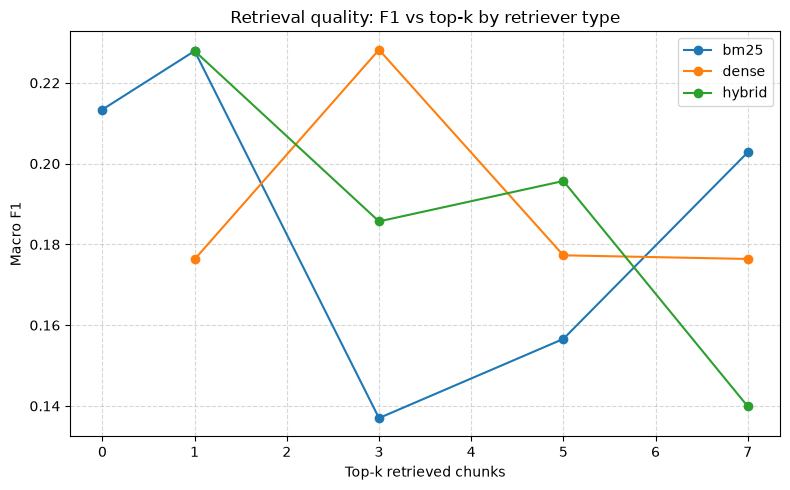

In [81]:
# CELL 18 — Top-k Sweep Plot
# Line chart showing how F1 changes as more chunks are retrieved (k=1,3,5,7)
# for each retriever type. Helps answer RQ1 — what is the optimal k?
# Expected pattern: F1 improves with k up to a point then plateaus or drops
# as irrelevant chunks start adding noise to the prompt.


# Summarise grouped by retriever and top-k
topk_summary = summarise(df_results, ["retriever", "top_k"])

fig, ax = plt.subplots(figsize=(8, 5))

# One line per retriever — sorted by k so the line plots left to right
for ret in CFG["retriever_types"]:
    sub = topk_summary[topk_summary["retriever"] == ret].sort_values("top_k")
    ax.plot(sub["top_k"], sub["macro_f1"], marker="o", label=ret)

ax.set_xlabel("Top-k retrieved chunks")
ax.set_ylabel("Macro F1")
ax.set_title("Retrieval quality: F1 vs top-k by retriever type")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

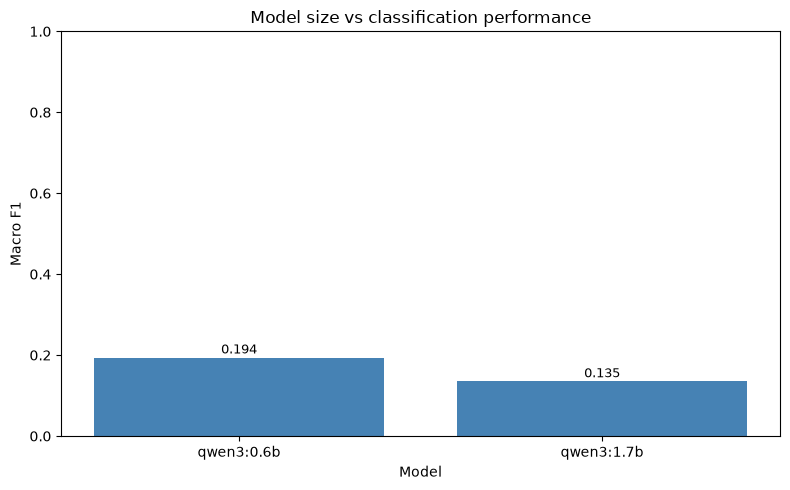

In [82]:
# CELL 19 — Model Size vs Performance Plot
# Bar chart comparing macro-F1 across model sizes (0.6b vs 1.7b).
# Answers RQ2 — does a larger model classify depression severity better?
# F1 values are annotated on top of each bar for easy reading.

# Summarise grouped by model only — averages across all other variables
model_summary = summarise(df_results, ["model"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_summary["model"], model_summary["macro_f1"], color="steelblue")
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.set_title("Model size vs classification performance")
ax.set_ylim(0, 1)

# Annotate each bar with its exact F1 value
for i, row in model_summary.iterrows():
    ax.text(i, row["macro_f1"] + 0.01, f"{row['macro_f1']:.3f}",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [83]:
# CELL 20 — Save Results and Error Analysis
# Saves two CSV files and prints a sample of misclassified posts:
#   rag_results_summary.csv        — aggregated metrics per configuration
#   error_analysis_best_config.csv — posts the best configuration got wrong
# The error analysis is useful for qualitative review — checking whether
# misclassifications are reasonable (e.g. mild predicted as moderate)
# or severe errors (e.g. minimum predicted as severe).

# Save the full summary table — one row per configuration
df_summary.to_csv("rag_results_summary.csv", index=False)
print("Summary saved to rag_results_summary.csv")

# Extract misclassified posts from the best configuration for error analysis
errors = best_df[best_df["correct"] == 0][
    ["true_label", "predicted", "answer_text", "chunk_ids"]
].reset_index(drop=True)
errors.to_csv("error_analysis_best_config.csv", index=False)
print(f"Error analysis: {len(errors)} misclassified posts saved to error_analysis_best_config.csv")

# Print a sample of errors — shows true label, predicted label, and model output
# chunk_ids shows which CDDR chunks were retrieved — useful for checking
# whether wrong predictions were caused by poor retrieval
print("\nSample errors:")
for _, r in errors.head(5).iterrows():
    print(f"  true={r['true_label']:8}  pred={r['predicted']:8}  output: {r['answer_text'][:80]}")

Summary saved to rag_results_summary.csv
Error analysis: 34 misclassified posts saved to error_analysis_best_config.csv

Sample errors:
  true=minimum   pred=moderate  output: Label: moderate  
Reason: Multiple severe symptoms causing considerable function
  true=mild      pred=moderate  output: Label: moderate  
Reason: Multiple severe symptoms causing considerable function
  true=mild      pred=moderate  output: Label: moderate  
Reason: Multiple severe symptoms causing considerable function
  true=mild      pred=moderate  output: Label: moderate  
Reason: Multiple severe symptoms causing considerable function
  true=moderate  pred=minimum   output: Label: minimum  
Reason: The user's message is a general statement about their m
